# Потребности студентов вузов при прохождении практики

**Качественное исследование (CustDev) по брифу VK Education**
Автор: Анастасия Щугарева · Москва, 2026

Ноутбук повторяет аналитическую часть отчёта: собирает открытые данные о практике и стажировках, проверяет квоты выборки, кодирует профили респондентов по темам, ранжирует боли и строит эмоциональную кривую пути студента (CJM).

**Структура**
1. Открытые данные: что известно о практике
2. Гипотезы и критерии проверки
3. Респонденты и проверка квот
4. Кодирование тем: ожидания, страхи, боли, идеальный результат
5. Ранжирование болей и барьеров
6. Сегменты и иерархия потребностей
7. Карта пути студента (CJM)
8. Статус гипотез и выводы

> Профили респондентов в разделе 3 — обобщённые портреты (прото-персоны), собранные по открытым опросам и публикациям из раздела 1. Гайд для полевых интервью лежит в отчёте, приложение А.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

pd.set_option('display.max_colwidth', 120)
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'figure.dpi': 110,
})

ACCENT, WARM, GREEN, AMBER, GREY = '#0077ff', '#e8562a', '#1f8a4c', '#b7791f', '#9a9aa3'

## 1. Открытые данные: что известно о практике

Все цифры взяты из первоисточников или крупных СМИ со ссылкой на исследование. Ссылки — в колонке `url`.

In [2]:
sources = pd.DataFrame([
    ('VK Education', 'мар 2025', 1200, 'Считают наличие практики важным в обучении', 70, 'https://vk.company/ru/press/releases/11984/'),
    ('VK Education', 'мар 2025', 1200, 'Важна перспектива трудоустройства', 71, 'https://vk.company/ru/press/releases/11984/'),
    ('VK Education', 'мар 2025', 1200, 'Хотят симуляции реальных задач', 50, 'https://vk.company/ru/press/releases/11984/'),
    ('SuperJob', 'апр–май 2026', 1000, 'Устроились в компанию, где стажировались', 72, 'https://tass.ru/obschestvo/27756175'),
    ('SuperJob', 'апр–май 2026', 1000, 'Получили предложение, но отказались', 11, 'https://tass.ru/obschestvo/27756175'),
    ('SuperJob', 'апр–май 2026', 1000, 'Не получили предложение', 7, 'https://tass.ru/obschestvo/27756175'),
    ('SuperJob (Самара)', 'июн 2026', None, 'Видят в стажировке способ получить опыт', 74, 'https://samaraonline24.ru/samara/view/bolee-poloviny-samarskih-stazerov-polucaut-rabotu-posle-praktiki'),
    ('SuperJob (Самара)', 'июн 2026', None, 'Компаний с формализованной программой стажировок', 30, 'https://samaraonline24.ru/samara/view/bolee-poloviny-samarskih-stazerov-polucaut-rabotu-posle-praktiki'),
    ('ГУУ', '2019', 525, 'Предпочитают место практики от вуза', 83.8, 'https://guu.ru/%D0%BA%D0%B0%D0%BA-%D0%B8-%D0%B3%D0%B4%D0%B5-%D0%BF%D1%80%D0%B5%D0%B4%D0%BF%D0%BE%D1%87%D0%B8%D1%82%D0%B0%D1%8E%D1%82-%D0%BF%D1%80%D0%BE%D1%85%D0%BE%D0%B4%D0%B8%D1%82%D1%8C-%D0%BF%D1%80%D0%B0%D0%BA/'),
    ('ГУУ', '2019', 525, 'Готовы искать место самостоятельно', 10.5, 'https://guu.ru/%D0%BA%D0%B0%D0%BA-%D0%B8-%D0%B3%D0%B4%D0%B5-%D0%BF%D1%80%D0%B5%D0%B4%D0%BF%D0%BE%D1%87%D0%B8%D1%82%D0%B0%D1%8E%D1%82-%D0%BF%D1%80%D0%BE%D1%85%D0%BE%D0%B4%D0%B8%D1%82%D1%8C-%D0%BF%D1%80%D0%B0%D0%BA/'),
    ('ГУУ', '2019', 525, 'Цель практики — профессиональные навыки', 28.9, 'https://guu.ru/%D0%BA%D0%B0%D0%BA-%D0%B8-%D0%B3%D0%B4%D0%B5-%D0%BF%D1%80%D0%B5%D0%B4%D0%BF%D0%BE%D1%87%D0%B8%D1%82%D0%B0%D1%8E%D1%82-%D0%BF%D1%80%D0%BE%D1%85%D0%BE%D0%B4%D0%B8%D1%82%D1%8C-%D0%BF%D1%80%D0%B0%D0%BA/'),
    ('ГУУ', '2019', 525, 'Цель практики — связи для карьеры', 27.4, 'https://guu.ru/%D0%BA%D0%B0%D0%BA-%D0%B8-%D0%B3%D0%B4%D0%B5-%D0%BF%D1%80%D0%B5%D0%B4%D0%BF%D0%BE%D1%87%D0%B8%D1%82%D0%B0%D1%8E%D1%82-%D0%BF%D1%80%D0%BE%D1%85%D0%BE%D0%B4%D0%B8%D1%82%D1%8C-%D0%BF%D1%80%D0%B0%D0%BA/'),
    ('ГУУ', '2019', 525, 'Цель практики — опыт', 23.6, 'https://guu.ru/%D0%BA%D0%B0%D0%BA-%D0%B8-%D0%B3%D0%B4%D0%B5-%D0%BF%D1%80%D0%B5%D0%B4%D0%BF%D0%BE%D1%87%D0%B8%D1%82%D0%B0%D1%8E%D1%82-%D0%BF%D1%80%D0%BE%D1%85%D0%BE%D0%B4%D0%B8%D1%82%D1%8C-%D0%BF%D1%80%D0%B0%D0%BA/'),
], columns=['источник', 'период', 'n', 'показатель', 'доля_%', 'url'])

sources[['источник', 'период', 'n', 'показатель', 'доля_%']]

,источник,период,n,показатель,доля_%
0,VK Education,мар 2025,1200.0,Считают наличие практики важным в обучении,70.0
1,VK Education,мар 2025,1200.0,Важна перспектива трудоустройства,71.0
2,VK Education,мар 2025,1200.0,Хотят симуляции реальных задач,50.0
3,SuperJob,апр–май 2026,1000.0,"Устроились в компанию, где стажировались",72.0
4,SuperJob,апр–май 2026,1000.0,"Получили предложение, но отказались",11.0
5,SuperJob,апр–май 2026,1000.0,Не получили предложение,7.0
6,SuperJob (Самара),июн 2026,NaN,Видят в стажировке способ получить опыт,74.0
7,SuperJob (Самара),июн 2026,NaN,Компаний с формализованной программой стажировок,30.0
8,ГУУ,2019,525.0,Предпочитают место практики от вуза,83.8
9,ГУУ,2019,525.0,Готовы искать место самостоятельно,10.5


Рост ожиданий за год: 36%


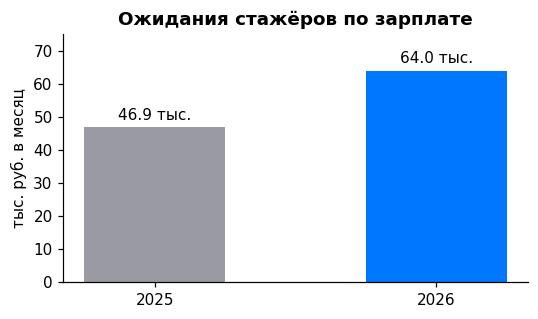

In [3]:
# Зарплатные ожидания стажёров, Changellenge (8 тыс.+ студентов 40 вузов), «Коммерсантъ», 16.01.2026
salary = pd.Series({'2025': 46.9, '2026': 64.0}, name='тыс. руб./мес')
growth = (salary['2026'] / salary['2025'] - 1) * 100
print(f'Рост ожиданий за год: {growth:.0f}%')

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(salary.index, salary.values, color=[GREY, ACCENT], width=0.5)
ax.bar_label(bars, fmt='%.1f тыс.', padding=3)
ax.set_title('Ожидания стажёров по зарплате')
ax.set_ylabel('тыс. руб. в месяц')
ax.set_ylim(0, 75)
plt.tight_layout(); plt.show()

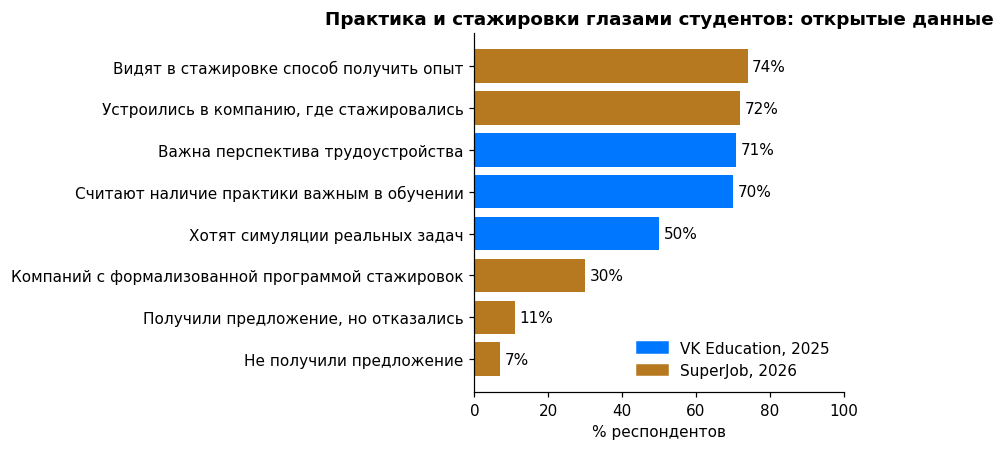

In [4]:
plot = sources[sources['источник'] != 'ГУУ'].sort_values('доля_%')
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [ACCENT if 'VK' in s else AMBER for s in plot['источник']]
bars = ax.barh(plot['показатель'], plot['доля_%'], color=colors)
ax.bar_label(bars, fmt='%.0f%%', padding=3)
ax.set_xlim(0, 100)
ax.set_title('Практика и стажировки глазами студентов: открытые данные')
ax.set_xlabel('% респондентов')
ax.legend(handles=[mpl.patches.Patch(color=ACCENT, label='VK Education, 2025'),
                   mpl.patches.Patch(color=AMBER, label='SuperJob, 2026')],
          loc='lower right', frameon=False)
plt.tight_layout(); plt.show()

**Что видно.** Спрос на практику прагматичный: студентам нужен опыт, который превращается в работу. При этом формальная программа для молодых людей есть меньше чем у трети компаний (данные по Самаре). Большинство студентов ждут место практики от вуза и не готовы искать его сами (ГУУ).

## 2. Гипотезы и критерии проверки

In [5]:
hypotheses = pd.DataFrame([
    ('H1', 'Ожидания', 'Главная ценность — опыт для резюме, а не оценка', '≥6 из 10 называют опыт/проект в топ-2 целей'),
    ('H2', 'Ожидания', 'Старшие курсы ждут предложения о работе', '≥3 из 5 старшекурсников хотят остаться'),
    ('H3', 'Ожидания', 'Нужен наставник, а не руководитель «на бумаге»', 'Наставник упомянут у ≥6 из 10'),
    ('H4', 'Страхи', 'Главный страх — рутина вместо профессии', 'Страх рутины у ≥5 из 10'),
    ('H5', 'Страхи', 'Боятся показаться некомпетентными', 'Неловкость спрашивать у ≥4 из 10'),
    ('H6', 'Боли', 'Самый трудный этап — поиск места', 'Назван самым трудным у ≥5 из 10'),
    ('H7', 'Боли', 'Бюрократия воспринимается как бессмысленная', 'В топ-3 раздражителей у ≥5 из 10'),
    ('H8', 'Боли', 'Работающие выбирают формальную практику', 'У работающих (≥2) практика формальная'),
    ('H9', 'Боли', 'Интересная бесплатная практика лучше скучной платной', '≥6 из 10 выбирают интересную'),
    ('H10', 'Идеал', 'Идеал — артефакт плюс ясность «моё/не моё»', 'Артефакт или вывод о профессии у ≥6 из 10'),
], columns=['id', 'блок', 'гипотеза', 'критерий'])
hypotheses

,id,блок,гипотеза,критерий
0,H1,Ожидания,"Главная ценность — опыт для резюме, а не оценка",≥6 из 10 называют опыт/проект в топ-2 целей
1,H2,Ожидания,Старшие курсы ждут предложения о работе,≥3 из 5 старшекурсников хотят остаться
2,H3,Ожидания,"Нужен наставник, а не руководитель «на бумаге»",Наставник упомянут у ≥6 из 10
3,H4,Страхи,Главный страх — рутина вместо профессии,Страх рутины у ≥5 из 10
4,H5,Страхи,Боятся показаться некомпетентными,Неловкость спрашивать у ≥4 из 10
5,H6,Боли,Самый трудный этап — поиск места,Назван самым трудным у ≥5 из 10
6,H7,Боли,Бюрократия воспринимается как бессмысленная,В топ-3 раздражителей у ≥5 из 10
7,H8,Боли,Работающие выбирают формальную практику,У работающих (≥2) практика формальная
8,H9,Боли,Интересная бесплатная практика лучше скучной платной,≥6 из 10 выбирают интересную
9,H10,Идеал,Идеал — артефакт плюс ясность «моё/не моё»,Артефакт или вывод о профессии у ≥6 из 10


## 3. Респонденты и проверка квот

Десять профилей, покрывающих квоты дизайна исследования: курс, направление, тип вуза, занятость, способ получения места практики.

In [6]:
resp = pd.DataFrame([
    ('R1', 'Кирилл',    21, '4 курс',        'IT и данные',        'столичный',   False, 'карьерная платформа', 'Карьерист'),
    ('R2', 'Алина',     20, '2–3 курс',      'экономика и менеджмент', 'региональный', False, 'от вуза',        'Исследователь'),
    ('R3', 'Дмитрий',   22, '4 курс',        'гуманитарные и юридические', 'столичный', True, 'по месту работы', 'Совместитель'),
    ('R4', 'Софья',     19, '2–3 курс',      'медиа и маркетинг',  'столичный',   False, 'от вуза',            'Исследователь'),
    ('R5', 'Тимур',     23, 'магистратура',  'IT и данные',        'частный',     True,  'от вуза',            'Формалист'),
    ('R6', 'Полина',    21, '4 курс',        'медиа и маркетинг',  'частный',     False, 'сам',                'Карьерист'),
    ('R7', 'Артём',     20, '2–3 курс',      'инженерные',         'региональный', False, 'от вуза',           'Исследователь'),
    ('R8', 'Вероника',  21, '4 курс',        'гуманитарные и юридические', 'региональный', False, 'через знакомых', 'Исследователь'),
    ('R9', 'Иван',      19, '2–3 курс',      'экономика и менеджмент', 'столичный', True,  'от вуза',            'Совместитель'),
    ('R10','Екатерина', 24, 'магистратура',  'гуманитарные и юридические', 'столичный', False, 'сам',           'Карьерист'),
], columns=['id', 'имя', 'возраст', 'курс', 'направление', 'тип_вуза', 'работает', 'место_практики', 'сегмент'])
resp

,id,имя,возраст,курс,направление,тип_вуза,работает,место_практики,сегмент
0,R1,Кирилл,21,4 курс,IT и данные,столичный,False,карьерная платформа,Карьерист
1,R2,Алина,20,2–3 курс,экономика и менеджмент,региональный,False,от вуза,Исследователь
2,R3,Дмитрий,22,4 курс,гуманитарные и юридические,столичный,True,по месту работы,Совместитель
3,R4,Софья,19,2–3 курс,медиа и маркетинг,столичный,False,от вуза,Исследователь
4,R5,Тимур,23,магистратура,IT и данные,частный,True,от вуза,Формалист
5,R6,Полина,21,4 курс,медиа и маркетинг,частный,False,сам,Карьерист
6,R7,Артём,20,2–3 курс,инженерные,региональный,False,от вуза,Исследователь
7,R8,Вероника,21,4 курс,гуманитарные и юридические,региональный,False,через знакомых,Исследователь
8,R9,Иван,19,2–3 курс,экономика и менеджмент,столичный,True,от вуза,Совместитель
9,R10,Екатерина,24,магистратура,гуманитарные и юридические,столичный,False,сам,Карьерист


In [7]:
quotas = {
    'курс':      {'2–3 курс': 4, '4 курс': 4, 'магистратура': 2},
    'тип_вуза':  {'столичный': 5, 'региональный': 3, 'частный': 2},
}
rows = []
for col, q in quotas.items():
    fact = resp[col].value_counts()
    for k, v in q.items():
        rows.append((col, k, v, int(fact.get(k, 0))))
check = pd.DataFrame(rows, columns=['параметр', 'значение', 'план', 'факт'])
check['ок'] = check['план'] == check['факт']

extra = pd.DataFrame([
    ('направлений покрыто (нужно 5)', resp['направление'].nunique() >= 5),
    ('работающих ≥ 2', resp['работает'].sum() >= 2),
    ('все способы получения места', {'от вуза','сам','через знакомых','карьерная платформа','по месту работы'} <= set(resp['место_практики'])),
], columns=['условие', 'ок'])

display(check); display(extra)
assert check['ок'].all() and extra['ок'].all(), 'Квоты не выполнены'
print('Все квоты выборки выполнены.')

,параметр,значение,план,факт,ок
0,курс,2–3 курс,4,4,True
1,курс,4 курс,4,4,True
2,курс,магистратура,2,2,True
3,тип_вуза,столичный,5,5,True
4,тип_вуза,региональный,3,3,True
5,тип_вуза,частный,2,2,True


,условие,ок
0,направлений покрыто (нужно 5),True
1,работающих ≥ 2,True
2,все способы получения места,True


Все квоты выборки выполнены.


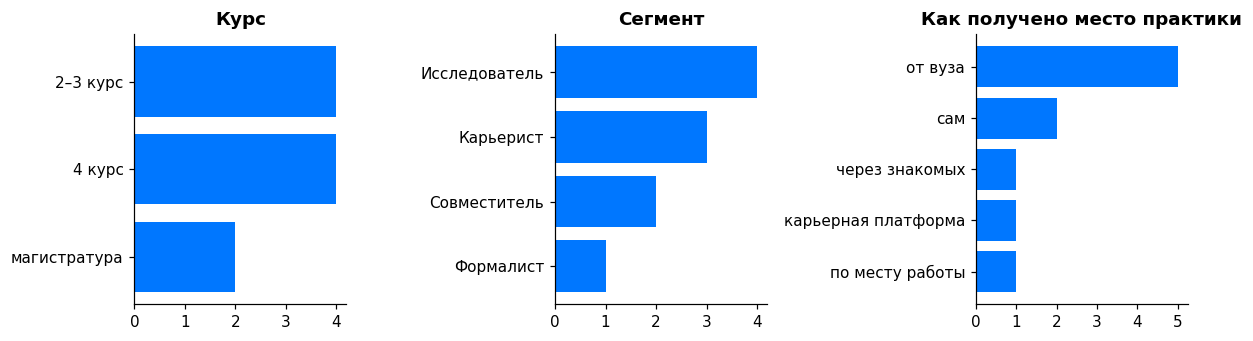

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, col, title in zip(axes, ['курс', 'сегмент', 'место_практики'],
                          ['Курс', 'Сегмент', 'Как получено место практики']):
    vc = resp[col].value_counts().sort_values()
    ax.barh(vc.index, vc.values, color=ACCENT)
    ax.set_title(title); ax.set_xticks(range(0, vc.max() + 1))
plt.tight_layout(); plt.show()

## 4. Кодирование тем

Каждый профиль размечен по темам кодировочной таблицы (отчёт, приложение В):
`1` — тема присутствует, `2` — присутствует сильно (эмоционально или студент пытался решить проблему сам), `0` — нет.

In [9]:
themes = {
    'ОЖ-1 Реальная задача':        [1, 2, 0, 1, 0, 2, 2, 1, 0, 1],
    'ОЖ-2 Наставник/обр. связь':   [1, 2, 0, 2, 0, 1, 1, 2, 0, 1],
    'ОЖ-3 Оффер':                  [2, 0, 0, 0, 0, 1, 0, 0, 0, 2],
    'СТ-1 Рутина, «мебель»':       [0, 2, 0, 0, 0, 2, 2, 1, 1, 0],
    'СТ-2 Показаться некомпетентным':[0, 1, 0, 2, 0, 0, 1, 0, 0, 0],
    'СТ-3 Не успеть проявить себя': [2, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    'БЛ-1 Поиск места':            [2, 2, 1, 0, 0, 2, 0, 1, 1, 1],
    'БЛ-2 Бюрократия':             [2, 0, 2, 0, 2, 0, 0, 0, 0, 1],
    'БЛ-3 Деньги, график':         [0, 0, 2, 0, 2, 1, 1, 1, 2, 0],
    'БЛ-4 Разрыв вуза и компании': [2, 0, 1, 0, 0, 0, 0, 0, 0, 2],
    'ИД-1 Артефакт':               [1, 1, 0, 1, 0, 2, 1, 0, 0, 2],
    'ИД-2 Ясность о профессии':    [0, 2, 0, 2, 0, 0, 1, 2, 0, 0],
}
coding = pd.DataFrame(themes, index=resp['id']).T
coding

id,R1,R2,R3,R4,R5,R6,R7,R8,R9,R10
ОЖ-1 Реальная задача,1,2,0,1,0,2,2,1,0,1
ОЖ-2 Наставник/обр. связь,1,2,0,2,0,1,1,2,0,1
ОЖ-3 Оффер,2,0,0,0,0,1,0,0,0,2
"СТ-1 Рутина, «мебель»",0,2,0,0,0,2,2,1,1,0
СТ-2 Показаться некомпетентным,0,1,0,2,0,0,1,0,0,0
СТ-3 Не успеть проявить себя,2,0,0,0,0,1,0,0,0,1
БЛ-1 Поиск места,2,2,1,0,0,2,0,1,1,1
БЛ-2 Бюрократия,2,0,2,0,2,0,0,0,0,1
"БЛ-3 Деньги, график",0,0,2,0,2,1,1,1,2,0
БЛ-4 Разрыв вуза и компании,2,0,1,0,0,0,0,0,0,2


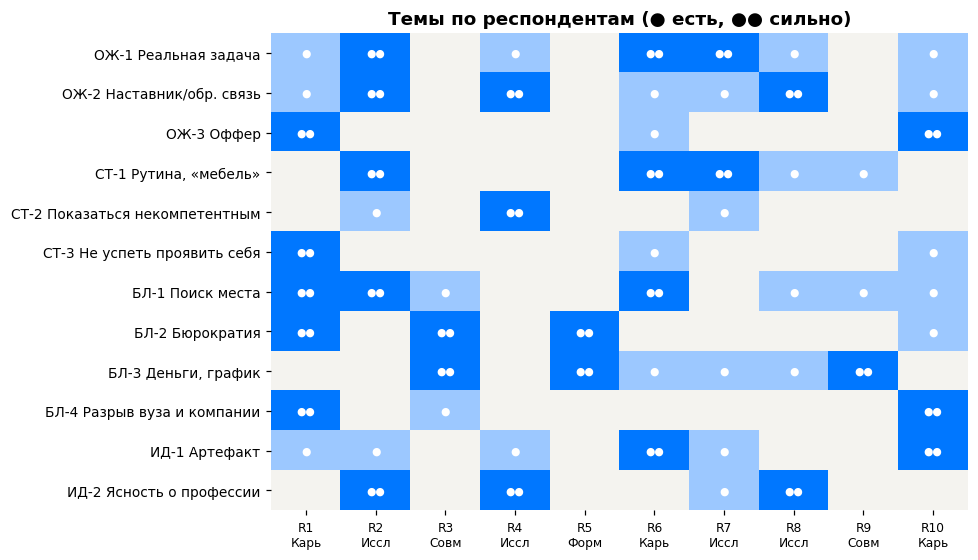

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.2))
cmap = mpl.colors.ListedColormap(['#f4f3ef', '#9cc8ff', ACCENT])
ax.imshow(coding.values, cmap=cmap, aspect='auto', vmin=0, vmax=2)
ax.set_xticks(range(len(coding.columns)), [f'{i}\n{s[:4]}' for i, s in zip(coding.columns, resp['сегмент'])], fontsize=8)
ax.set_yticks(range(len(coding.index)), coding.index, fontsize=9)
for (i, j), v in np.ndenumerate(coding.values):
    if v: ax.text(j, i, '●' if v == 1 else '●●', ha='center', va='center', color='white', fontsize=7)
ax.set_title('Темы по респондентам (● есть, ●● сильно)')
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()

In [11]:
summary = pd.DataFrame({
    'упоминаний': (coding > 0).sum(axis=1),
    'сильных': (coding == 2).sum(axis=1),
    'сегментов': coding.apply(lambda r: resp.loc[r.values > 0, 'сегмент'].nunique(), axis=1),
})
summary['вес'] = summary['упоминаний'] + summary['сильных']
summary['устойчивая'] = (summary['упоминаний'] >= 3) & (summary['сегментов'] >= 2)
summary = summary.sort_values('вес', ascending=False)
summary

,упоминаний,сильных,сегментов,вес,устойчивая
ОЖ-1 Реальная задача,7,3,2,10,True
ОЖ-2 Наставник/обр. связь,7,3,2,10,True
БЛ-1 Поиск места,7,3,3,10,True
"БЛ-3 Деньги, график",6,3,4,9,True
ИД-1 Артефакт,6,2,2,8,True
"СТ-1 Рутина, «мебель»",5,3,3,8,True
ИД-2 Ясность о профессии,4,3,1,7,False
БЛ-2 Бюрократия,4,3,3,7,True
ОЖ-3 Оффер,3,2,1,5,False
БЛ-4 Разрыв вуза и компании,3,2,2,5,True


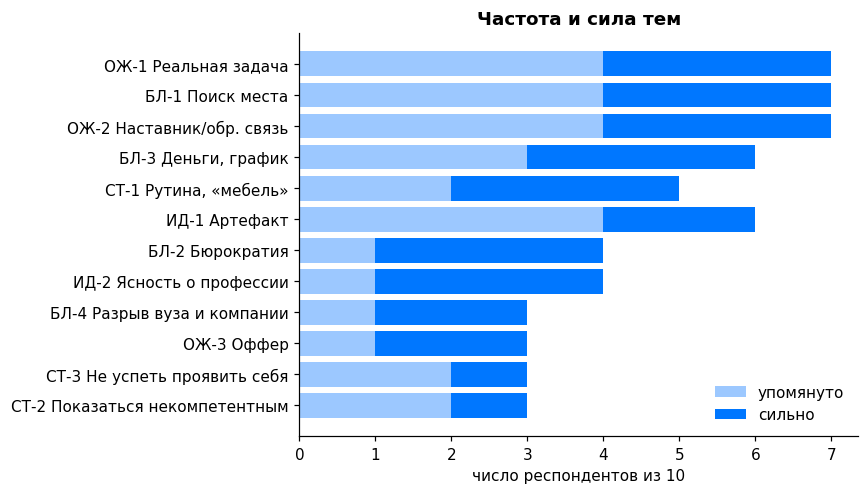

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.6))
s = summary.sort_values('вес')
ax.barh(s.index, s['упоминаний'] - s['сильных'], color='#9cc8ff', label='упомянуто')
ax.barh(s.index, s['сильных'], left=s['упоминаний'] - s['сильных'], color=ACCENT, label='сильно')
ax.set_xlabel('число респондентов из 10')
ax.set_title('Частота и сила тем')
ax.legend(frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

**Вывод по кодированию.** Сильнее всего звучат поиск места, реальная задача и наставник. Страх рутины сосредоточен у исследователей и карьеристов, деньги и график — у совместителей. Тема «оффер» узкая: она есть почти только у карьеристов, зато там она главная.

## 5. Ранжирование болей и барьеров

In [13]:
pains = pd.DataFrame([
    ('Поиск места',              'Поиск',             3, 3),
    ('Формальное содержание',    'Работа',            3, 2),
    ('Нет наставника',           'Работа',            3, 2),
    ('Бюрократия',               'Оформление, отчёт', 2, 3),
    ('Несовпадение сроков',      'Поиск',             2, 2),
    ('Конфликт с работой',       'Поиск, работа',     2, 3),
    ('Деньги',                   'Работа',            2, 2),
    ('Нет продолжения',          'После',             2, 1),
    ('Разрыв вуза и компании',   'Отчёт',             1, 1),
], columns=['боль', 'этап', 'распространённость', 'самостоятельные_попытки'])
# 1 — низкая, 2 — средняя, 3 — высокая
pains['сила'] = pains['распространённость'] * 2 + pains['самостоятельные_попытки']
pains['уровень'] = pd.cut(pains['сила'], [0, 5, 7, 9], labels=['ниже средней', 'средняя', 'высокая'])
pains.sort_values('сила', ascending=False).reset_index(drop=True)

,боль,этап,распространённость,самостоятельные_попытки,сила,уровень
0,Поиск места,Поиск,3,3,9,высокая
1,Формальное содержание,Работа,3,2,8,высокая
2,Нет наставника,Работа,3,2,8,высокая
3,Бюрократия,"Оформление, отчёт",2,3,7,средняя
4,Конфликт с работой,"Поиск, работа",2,3,7,средняя
5,Несовпадение сроков,Поиск,2,2,6,средняя
6,Деньги,Работа,2,2,6,средняя
7,Нет продолжения,После,2,1,5,ниже средней
8,Разрыв вуза и компании,Отчёт,1,1,3,ниже средней


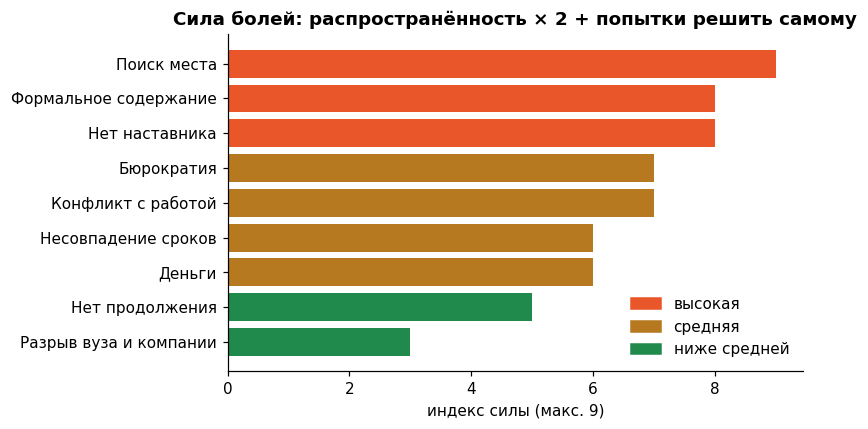

In [14]:
p = pains.sort_values('сила')
col = {'высокая': WARM, 'средняя': AMBER, 'ниже средней': GREEN}
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(p['боль'], p['сила'], color=[col[str(x)] for x in p['уровень']])
ax.set_title('Сила болей: распространённость × 2 + попытки решить самому')
ax.set_xlabel('индекс силы (макс. 9)')
ax.legend(handles=[mpl.patches.Patch(color=c, label=l) for l, c in col.items()], frameon=False, loc='lower right')
plt.tight_layout(); plt.show()

## 6. Сегменты и иерархия потребностей

In [15]:
seg = resp.groupby('сегмент').agg(человек=('id', 'count'), кто=('имя', ', '.join))
top_theme = {s: coding.loc[:, resp.loc[resp['сегмент'] == s, 'id']].sum(axis=1).idxmax() for s in seg.index}
seg['главная_тема'] = pd.Series(top_theme)
seg

,человек,кто,главная_тема
сегмент,,,
Исследователь,4,"Алина, Софья, Артём, Вероника",ОЖ-2 Наставник/обр. связь
Карьерист,3,"Кирилл, Полина, Екатерина",ОЖ-3 Оффер
Совместитель,2,"Дмитрий, Иван","БЛ-3 Деньги, график"
Формалист,1,Тимур,БЛ-2 Бюрократия


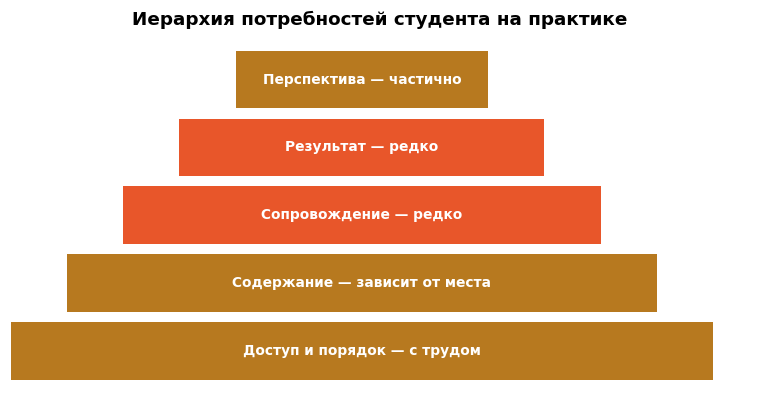

In [16]:
needs = pd.DataFrame([
    (5, 'Перспектива',   'Оффер, понятный следующий шаг',              'частично'),
    (4, 'Результат',     'Артефакт, рекомендация, ясность о профессии', 'редко'),
    (3, 'Сопровождение', 'Наставник, обратная связь, право на ошибку',  'редко'),
    (2, 'Содержание',    'Реальная задача по специальности',            'зависит от места'),
    (1, 'Доступ и порядок', 'Найти место, оформить, совместить с работой', 'с трудом'),
], columns=['уровень', 'потребность', 'суть', 'закрыта_сейчас'])

fig, ax = plt.subplots(figsize=(7, 3.8))
colmap = {'частично': AMBER, 'редко': WARM, 'зависит от места': AMBER, 'с трудом': AMBER}
for _, r in needs.iterrows():
    w = 10 - (r['уровень'] - 1) * 1.6
    ax.barh(r['уровень'], w, left=(10 - w) / 2, height=0.85, color=colmap[r['закрыта_сейчас']])
    ax.text(5, r['уровень'], f"{r['потребность']} — {r['закрыта_сейчас']}", ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.axis('off'); ax.set_title('Иерархия потребностей студента на практике')
plt.tight_layout(); plt.show()

**Ответ на главный вопрос исследования.** Преобладают две потребности: содержательная работа с обратной связью (уровни 2–3) и доступ к хорошему месту практики (уровень 1). Первая сильнее как ожидание, вторая — как боль. Перспектива трудоустройства важна старшекурсникам, но без нижних уровней она недостижима.

## 7. Карта пути студента (CJM)

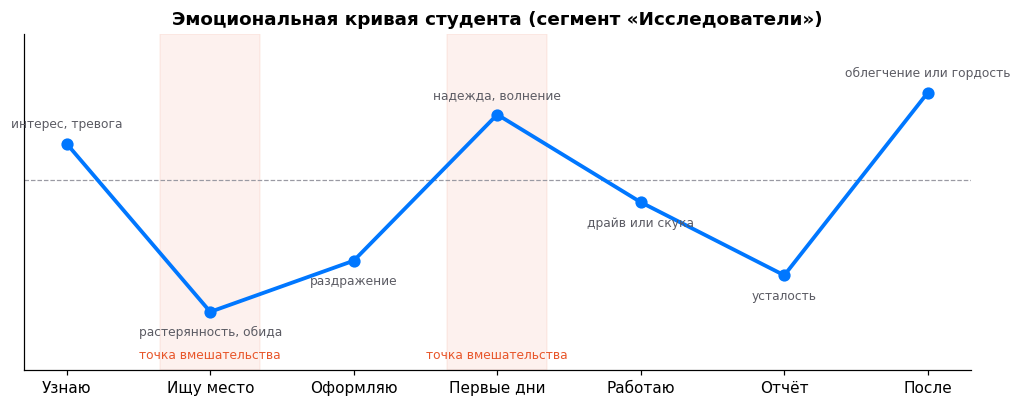

,этап,эмоция,чувства,боль
0,Узнаю,0.5,"интерес, тревога","Требования размыты, информация в чатах"
1,Ищу место,-1.8,"растерянность, обида","Короткий список, отказы, неравенство связей"
2,Оформляю,-1.1,раздражение,"Разные шаблоны, долгое согласование"
3,Первые дни,0.9,"надежда, волнение",Нет плана и наставника
4,Работаю,-0.3,драйв или скука,"Рутина, нет обратной связи"
5,Отчёт,-1.3,усталость,Дневник задним числом
6,После,1.2,облегчение или гордость,Контакт теряется


In [17]:
cjm = pd.DataFrame([
    ('Узнаю',      0.5,  'интерес, тревога',        'Требования размыты, информация в чатах'),
    ('Ищу место', -1.8,  'растерянность, обида',    'Короткий список, отказы, неравенство связей'),
    ('Оформляю',  -1.1,  'раздражение',             'Разные шаблоны, долгое согласование'),
    ('Первые дни', 0.9,  'надежда, волнение',       'Нет плана и наставника'),
    ('Работаю',   -0.3,  'драйв или скука',         'Рутина, нет обратной связи'),
    ('Отчёт',     -1.3,  'усталость',               'Дневник задним числом'),
    ('После',      1.2,  'облегчение или гордость', 'Контакт теряется'),
], columns=['этап', 'эмоция', 'чувства', 'боль'])

fig, ax = plt.subplots(figsize=(9.5, 3.8))
x = np.arange(len(cjm))
ax.axhline(0, color=GREY, lw=0.8, ls='--')
ax.plot(x, cjm['эмоция'], color=ACCENT, lw=2.5, marker='o', ms=7)
for i, r in cjm.iterrows():
    ax.annotate(r['чувства'], (i, r['эмоция']), textcoords='offset points',
                xytext=(0, 10 if r['эмоция'] >= 0 else -16), ha='center', fontsize=8, color='#5b5b63')
for i in (1, 3):
    ax.axvspan(i - 0.35, i + 0.35, color=WARM, alpha=0.08)
ax.set_xticks(x, cjm['этап']); ax.set_yticks([]); ax.set_ylim(-2.6, 2)
ax.set_title('Эмоциональная кривая студента (сегмент «Исследователи»)')
ax.text(1, -2.45, 'точка вмешательства', ha='center', color=WARM, fontsize=8)
ax.text(3, -2.45, 'точка вмешательства', ha='center', color=WARM, fontsize=8)
plt.tight_layout(); plt.show()
cjm

## 8. Статус гипотез и выводы

In [18]:
status = {'H1':'подтверждается','H2':'подтверждается','H3':'подтверждается','H4':'подтверждается',
          'H5':'частично','H6':'подтверждается','H7':'частично','H8':'подтверждается',
          'H9':'частично','H10':'подтверждается'}
hypotheses['статус'] = hypotheses['id'].map(status)
display(hypotheses[['id', 'гипотеза', 'статус']])
print(hypotheses['статус'].value_counts().to_string())

,id,гипотеза,статус
0,H1,"Главная ценность — опыт для резюме, а не оценка",подтверждается
1,H2,Старшие курсы ждут предложения о работе,подтверждается
2,H3,"Нужен наставник, а не руководитель «на бумаге»",подтверждается
3,H4,Главный страх — рутина вместо профессии,подтверждается
4,H5,Боятся показаться некомпетентными,частично
5,H6,Самый трудный этап — поиск места,подтверждается
6,H7,Бюрократия воспринимается как бессмысленная,частично
7,H8,Работающие выбирают формальную практику,подтверждается
8,H9,Интересная бесплатная практика лучше скучной платной,частично
9,H10,Идеал — артефакт плюс ясность «моё/не моё»,подтверждается


статус
подтверждается    7
частично          3


### Главное

1. **Основная потребность** — настоящая задача и живая обратная связь. Ради них студенты готовы мириться с бумагами и даже с отсутствием оплаты.
2. **Самый болезненный этап** — поиск места. Хуже всего тем, у кого нет связей и опыта в резюме.
3. **Главный страх** — оказаться «мебелью»: месяц рутины и характеристика, которую студент пишет себе сам.
4. **Потребности зависят от сегмента.** Карьеристам нужен оффер, исследователям — понять профессию, совместителям — не потерять заработок, формалистам — закрыть требование без сюрпризов.
5. **Идеальный результат измерим:** артефакт для портфолио, рекомендация наставника, ясность «моё — не моё» и, для части студентов, предложение о работе.

### Рекомендации коротко

| Кому | Что сделать |
|---|---|
| Вузу | Витрина мест практики с описанием задач; упрощённый зачёт стажировок и работы по профилю |
| Компаниям | Наставник по имени, план на первую неделю, мини-проект с итогом, разговор о перспективах в конце |
| VK Education | Кейс-трек как форма практики, сертификат с описанием проекта, прозрачный мостик в стажировку |

### Источники
- Приказ Минобрнауки и Минпросвещения от 05.08.2020 № 885/390 — https://base.garant.ru/74626874/
- VK Education, пресс-релиз 27.03.2025 — https://vk.company/ru/press/releases/11984/
- SuperJob / ТАСС, 2026 — https://tass.ru/obschestvo/27756175
- SuperJob по Самаре, 28.06.2026 — https://samaraonline24.ru/samara/view/bolee-poloviny-samarskih-stazerov-polucaut-rabotu-posle-praktiki
- Changellenge / «Коммерсантъ», 16.01.2026 — https://www.kommersant.ru/doc/8342609
- Changellenge Best Company Award 2026 — https://changellenge.com/tpage/bca-2026-results/
- Опрос ГУУ, 2019 — https://guu.ru/%D0%BA%D0%B0%D0%BA-%D0%B8-%D0%B3%D0%B4%D0%B5-%D0%BF%D1%80%D0%B5%D0%B4%D0%BF%D0%BE%D1%87%D0%B8%D1%82%D0%B0%D1%8E%D1%82-%D0%BF%D1%80%D0%BE%D1%85%D0%BE%D0%B4%D0%B8%D1%82%D1%8C-%D0%BF%D1%80%D0%B0%D0%BA/
- «Учительская газета», 03.10.2023 — https://ug.ru/na-plyus-vsegda-najdetsya-minus/
- hh.ru, «Стажировка vs практика», 28.04.2025 — https://hh.ru/article/28552
- Guest G., Bunce A., Johnson L. How Many Interviews Are Enough? // Field Methods. 2006. 18(1). P. 59–82. DOI: 10.1177/1525822X05279903